In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
labcraft_platemap = pd.read_csv("data/concentration_key.csv")
labcraft_platemap = labcraft_platemap.fillna(0)
labcraft_platemap = labcraft_platemap.rename(columns={'Well ID': 'well_id'})
labcraft_platemap = labcraft_platemap.set_index("well_id")
labcraft_platemap = labcraft_platemap.drop(columns=['[PMix]_mg/mL', '[DNA]_nM']) #did not use labcraft here

samples = pd.read_csv("data/samples_titration.csv", index_col="well_id")
samples["Type"] = "Sample"

In [4]:
samples.columns

Index(['Name', '[DNA] (nM)', '[RNAse Inhib] (U/mL)', '[PMix] (mg/mL)',
       '[Ribosome] (uM)', 'Rxn Volume (uL)', '[Magnesium acetate] (mM)',
       '[Creatine phosphate] (mM)', '[Potassium glutamate] (mM)', 'hepes mM',
       'ppk uM', 'polyphosphate mM', 'atp mM', 'gtp mM', 'ctp mM', 'utp mM',
       'tcep mM', 'folinic_acid mM', 'spermidine mM', 'aas mM', 'trna ug/ul',
       '[DNA] (nM) conc_to_add', '[DNA] (nM) vol_to_pipette_ul',
       '[PMix] (mg/mL) conc_to_add', '[PMix] (mg/mL) vol_to_pipette_ul',
       '[Magnesium acetate] (mM) conc_to_add',
       '[Magnesium acetate] (mM) vol_to_pipette_ul',
       '[Creatine phosphate] (mM) conc_to_add',
       '[Creatine phosphate] (mM) vol_to_pipette_ul',
       '[Potassium glutamate] (mM) conc_to_add',
       '[Potassium glutamate] (mM) vol_to_pipette_ul',
       'base_master_mix_vol_to_add_ul', 'total_titration_vol_to_add_ul',
       'buffer_vol_to_add_ul', 'total_vol_check_ul', 'Type'],
      dtype='object')

In [5]:
labcraft_platemap.columns

Index(['[Creatine phosphate]_mM', '[Magnesium acetate]_mM',
       '[Potassium glutamate]_mM', 'Water_--'],
      dtype='object')

In [6]:
# samples = samples.reset_index()
samples.head()

,Name,[DNA] (nM),[RNAse Inhib] (U/mL),[PMix] (mg/mL),[Ribosome] (uM),Rxn Volume (uL),[Magnesium acetate] (mM),[Creatine phosphate] (mM),[Potassium glutamate] (mM),hepes mM,...,[Magnesium acetate] (mM) vol_to_pipette_ul,[Creatine phosphate] (mM) conc_to_add,[Creatine phosphate] (mM) vol_to_pipette_ul,[Potassium glutamate] (mM) conc_to_add,[Potassium glutamate] (mM) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
well_id,,,,,,,,,,,,,,,,,,,,,
J16,1,3.00,2000.00,1.80,1.80,10.00,20.00,20.00,100.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,1.95,1.98,10.00,Sample
H9,1,3.00,2000.00,1.80,1.80,10.00,20.00,20.00,100.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,1.95,1.98,10.00,Sample
J10,1,3.00,2000.00,1.80,1.80,10.00,20.00,20.00,100.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,1.95,1.98,10.00,Sample
G16,2,3.00,2000.00,1.95,1.80,10.00,20.00,20.00,100.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,2.05,1.88,10.00,Sample
I14,2,3.00,2000.00,1.95,1.80,10.00,20.00,20.00,100.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,2.05,1.88,10.00,Sample


In [7]:
# Map concentration_key column names to samples column names
col_rename = {
    '[Creatine phosphate]_mM': '[Creatine phosphate] (mM)',
    '[Magnesium acetate]_mM': '[Magnesium acetate] (mM)',
    '[Potassium glutamate]_mM': '[Potassium glutamate] (mM)',
}
labcraft_platemap = labcraft_platemap.rename(columns=col_rename)


# --- Add base master mix contributions to get true final concentrations ---
base_mm = pd.read_csv("data/base_master_mix.csv", index_col="reagent")
base_mg   = base_mm.loc['magnesium_acetate', 'base_conc']    # 2.469 mM
base_kglu = base_mm.loc['potassium_glutamate', 'base_conc']  # 60.0 mM
# Creatine phosphate not in base_mm → base contribution is 0

labcraft_platemap['[Magnesium acetate] (mM)']   += base_mg
labcraft_platemap['[Potassium glutamate] (mM)'] += base_kglu


In [8]:
!pwd

/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/clean/20260306-discoveryplate-aria-r0


In [9]:


# Overwrite common concentration columns in samples with labcraft_platemap values
# Use .update() so only matching well_ids are overwritten (no NaNs for missing wells)
common_cols = labcraft_platemap.columns.intersection(samples.columns).tolist()
samples.update(labcraft_platemap[common_cols])
print(f"Updated {len(common_cols)} columns in samples from labcraft_platemap: {common_cols}")
samples.head()

Updated 3 columns in samples from labcraft_platemap: ['[Creatine phosphate] (mM)', '[Magnesium acetate] (mM)', '[Potassium glutamate] (mM)']


,Name,[DNA] (nM),[RNAse Inhib] (U/mL),[PMix] (mg/mL),[Ribosome] (uM),Rxn Volume (uL),[Magnesium acetate] (mM),[Creatine phosphate] (mM),[Potassium glutamate] (mM),hepes mM,...,[Magnesium acetate] (mM) vol_to_pipette_ul,[Creatine phosphate] (mM) conc_to_add,[Creatine phosphate] (mM) vol_to_pipette_ul,[Potassium glutamate] (mM) conc_to_add,[Potassium glutamate] (mM) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
well_id,,,,,,,,,,,,,,,,,,,,,
J16,1,3.00,2000.00,1.80,1.80,10.00,24.97,100.00,60.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,1.95,1.98,10.00,Sample
H9,1,3.00,2000.00,1.80,1.80,10.00,4.97,0.00,140.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,1.95,1.98,10.00,Sample
J10,1,3.00,2000.00,1.80,1.80,10.00,2.47,67.00,200.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,1.95,1.98,10.00,Sample
G16,2,3.00,2000.00,1.95,1.80,10.00,12.47,0.00,100.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,2.05,1.88,10.00,Sample
I14,2,3.00,2000.00,1.95,1.80,10.00,4.97,0.00,140.00,50.00,...,0.17,20.00,0.20,40.00,0.16,6.07,2.05,1.88,10.00,Sample


In [10]:
# Add standard wells not in DOE samples
standards = pd.DataFrame([
    {"well_id": "K8", "Type": "Standard", "Name": "Standard"},
    {"well_id": "K9", "Type": "Standard", "Name": "Standard"},
    {"well_id": "K10", "Type": "Standard", "Name": "Standard"},
]).set_index("well_id")
samples = pd.concat([samples, standards])
samples["[Magnesium acetate] (mM)"] = samples["[Magnesium acetate] (mM)"].apply(lambda x: x*95.2/203.3) # Perhaps through artifact miststake, we used the wrong calculation, so inpute Mg might have been wrong
samples["Well"] = samples.index

samples.to_csv("data/samples_final.csv")


In [11]:
samples.Well.unique()

array(['J16', 'H9', 'J10', 'G16', 'I14', 'G11', 'G12', 'G10', 'I15',
       'I12', 'I10', 'I11', 'G8', 'J9', 'I8', 'H8', 'J13', 'G15', 'G14',
       'H11', 'H15', 'J11', 'G13', 'G9', 'J12', 'H16', 'H12', 'I13',
       'H14', 'H13', 'I9', 'J14', 'J15', 'I16', 'H10', 'J8', 'K8', 'K9',
       'K10'], dtype=object)

In [12]:
# Specify file paths
data_file = "data/20260309-123116-cytation5-pure-timecourse-gfp-biotek-cdk.txt"
platemap_file = "data/samples_final.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()
# data["conditions"] = data.groupby(factors).ngroup()
# data["Name"] = data["conditions"]

# data = data[~data["Column"].isin([19])]

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,well_id,Name,...,[Magnesium acetate] (mM) vol_to_pipette_ul,[Creatine phosphate] (mM) conc_to_add,[Creatine phosphate] (mM) vol_to_pipette_ul,[Potassium glutamate] (mM) conc_to_add,[Potassium glutamate] (mM) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type
0,0 days 00:00:23,G8,383,G,8,GFP-Gext,Plate 1,2026-03-09 12:31:39,G8,5,...,0.11,0.00,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample
1,0 days 00:05:23,G8,341,G,8,GFP-Gext,Plate 1,2026-03-09 12:36:39,G8,5,...,0.11,0.00,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample
2,0 days 00:10:23,G8,401,G,8,GFP-Gext,Plate 1,2026-03-09 12:41:39,G8,5,...,0.11,0.00,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample
3,0 days 00:15:23,G8,878,G,8,GFP-Gext,Plate 1,2026-03-09 12:46:39,G8,5,...,0.11,0.00,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample
4,0 days 00:20:23,G8,2301,G,8,GFP-Gext,Plate 1,2026-03-09 12:51:39,G8,5,...,0.11,0.00,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample


In [13]:
data.Well.unique()

array(['G8', 'G9', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'H8',
       'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'I8', 'I9',
       'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'J8', 'J9', 'J10',
       'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'K8', 'K9', 'K10'],
      dtype=object)

## Plot Raw Curves

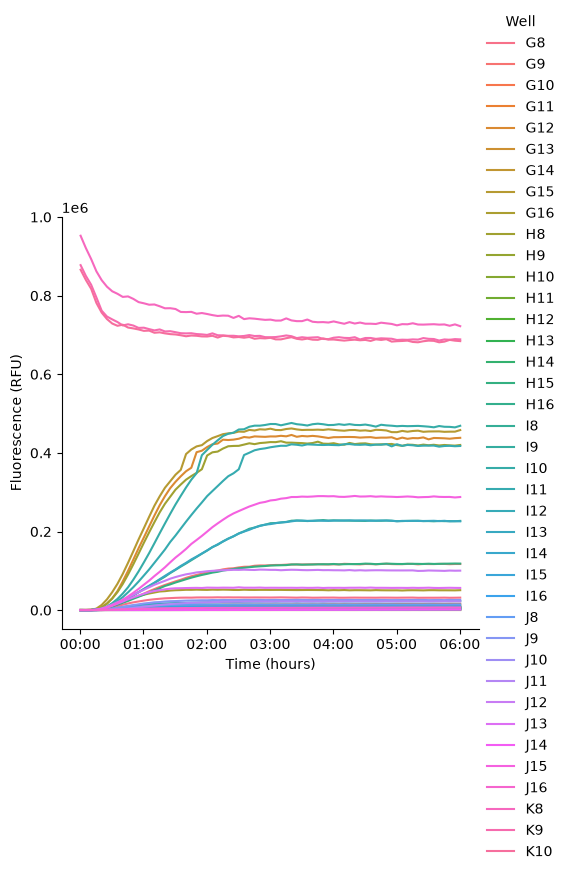

In [14]:
g = pr.plot_curves(data=data, hue="Well")#[data.Type == "Sample"]) #, hue="conditions")

In [15]:
data.Name.unique()

array(['5', '8', '3', '2', '7', '6', '1', '12', '9', '10', '11', '4',
       'Standard'], dtype=object)

## Normalize Data

In [16]:
data = pr.normalize_data_to_controls(data, ctrl_name = 'Standard')

Data Normalized to Standard in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

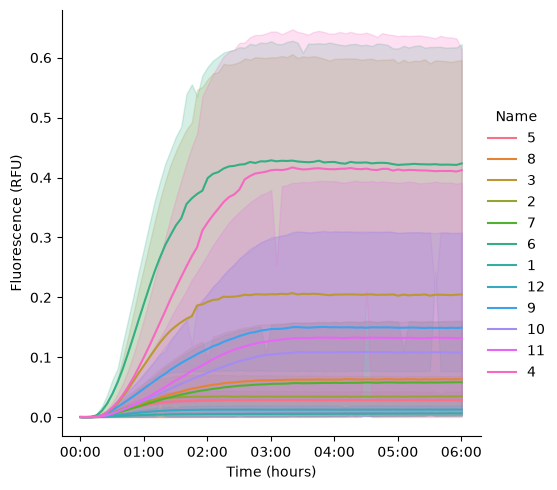

In [17]:
g = pr.plot_curves(data=data[data.Type == "Sample"])

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [18]:
data.columns
FACTOR_COLS = ['[PMix] (mg/mL)','[DNA] (nM)','[Magnesium acetate] (mM)','[Potassium glutamate] (mM)', '[Creatine phosphate] (mM)']

In [19]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well',  *FACTOR_COLS],  # Group by experimental condition
)
# kinetics = kinetics.reset_index()
kinetics.head()

Velocity  \
                                                                                                                                  Time   
Well [PMix] (mg/mL) [DNA] (nM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [Creatine phosphate] (mM)                             
G8   1.83           3.00       5.84                     100.00                     0.00                      0 days 00:45:05.000477904   
G9   1.56           1.00       11.69                    122.50                     71.00                     0 days 01:12:00.449124336   
G10  1.95           3.00       11.69                    60.00                      100.00                    0 days 00:55:17.524272784   
G11  1.95           3.00       5.84                     72.50                      49.00                     0 days 00:55:17.525180060   
G12  1.95           3.00       7.01                     140.00                     20.00                     0 days 01:06:22.002063246   

                                                                                                                              \
                                                                                                             data_normalized   
Well [PMix] (mg/mL) [DNA] (nM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [Creatine phosphate] (mM)                   
G8   1.83           3.00       5.84                     100.00                     0.00                                 0.02   
G9   1.56           1.00       11.69                    122.50                     71.00                                0.08   
G10  1.95           3.00       11.69                    60.00                      100.00                               0.01   
G11  1.95           3.00       5.84                     72.50                      49.00                                0.01   
G12  1.95           3.00       7.01                     140.00                     20.00                                0.30   

                                                                                                                   \
                                                                                                              Max   
Well [PMix] (mg/mL) [DNA] (nM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [Creatine phosphate] (mM)        
G8   1.83           3.00       5.84                     100.00                     0.00                      0.05   
G9   1.56           1.00       11.69                    122.50                     71.00                     0.09   
G10  1.95           3.00       11.69                    60.00                      100.00                    0.01   
G11  1.95           3.00       5.84                     72.50                      49.00                     0.02   
G12  1.95           3.00       7.01                     140.00                     20.00                     0.48   

                                                                                                                                   Lag  \
                                                                                                                                  Time   
Well [PMix] (mg/mL) [DNA] (nM) [Magnesium acetate] (mM) [Potassium glutamate] (mM) [Creatine phosphate] (mM)                             
G8   1.83           3.00       5.84                     100.00                     0.00                      0 days 00:18:48.643266592   
G9   1.56           1.00       11.69                    122.50                     71.00                     0 days 00:21:28.940117076   
G10  1.95           3.00       11.69                    60.00                      100.00                    0 days 00:25:06.691073142   
G11  1.95           3.00       5.84                     72.50                      49.00                     0 days 00:23:04.669448863   
G12  1.95           3.00       7.01                     140.00                     20.00     

In [20]:
data.head()

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,well_id,Name,...,[Creatine phosphate] (mM) vol_to_pipette_ul,[Potassium glutamate] (mM) conc_to_add,[Potassium glutamate] (mM) vol_to_pipette_ul,base_master_mix_vol_to_add_ul,total_titration_vol_to_add_ul,buffer_vol_to_add_ul,total_vol_check_ul,Type,ctrl_ints,data_normalized
0,0 days 00:00:23,G8,383,G,8,GFP-Gext,Plate 1,2026-03-09 12:31:39,G8,5,...,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample,735760.95,0.00
1,0 days 00:05:23,G8,341,G,8,GFP-Gext,Plate 1,2026-03-09 12:36:39,G8,5,...,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample,735760.95,0.00
2,0 days 00:10:23,G8,401,G,8,GFP-Gext,Plate 1,2026-03-09 12:41:39,G8,5,...,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample,735760.95,0.00
3,0 days 00:15:23,G8,878,G,8,GFP-Gext,Plate 1,2026-03-09 12:46:39,G8,5,...,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample,735760.95,0.00
4,0 days 00:20:23,G8,2301,G,8,GFP-Gext,Plate 1,2026-03-09 12:51:39,G8,5,...,0.00,40.00,0.16,6.07,1.71,2.23,10.00,Sample,735760.95,0.00


## Visualize Fits on Individual Wells

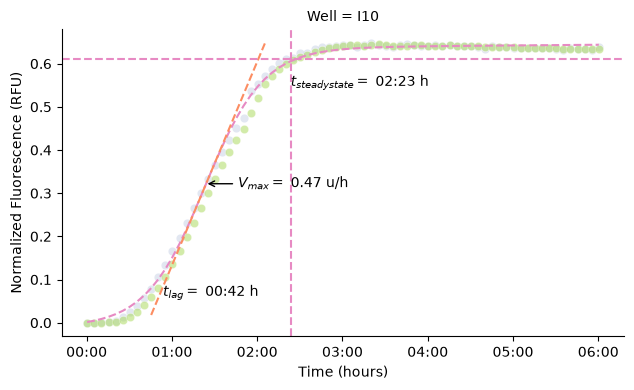

In [21]:
# Plot kinetic fits 
g = pr.plot_kinetics(data[data.Well == "I10"],  group_by=['Well', 'well_id', *FACTOR_COLS])

## Summary Plots

In [22]:
# pr.plot_summary(data)

In [23]:
responses = ["steady_state", "vmax", "lag_time_min"]

kin = kinetics.reset_index()
kin.columns = [
    "_".join([str(x).replace(" ", "_") for x in col if x])
    for col in kin.columns
]
factors = [str(x).replace(" ", "_") for x in FACTOR_COLS]
kin.head()

,Well,[PMix]_(mg/mL),[DNA]_(nM),[Magnesium_acetate]_(mM),[Potassium_glutamate]_(mM),[Creatine_phosphate]_(mM),Velocity_Time,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit
0,G8,1.83,3.00,5.84,100.00,0.00,0 days 00:45:05.000477904,0.02,0.05,0 days 00:18:48.643266592,0.01,0 days 01:23:45.744285609,0.04,"[0.043566922018340774, 4.567492667565475, 0.75...",1.00,0.00,True
1,G9,1.56,1.00,11.69,122.50,71.00,0 days 01:12:00.449124336,0.08,0.09,0 days 00:21:28.940117076,0.01,0 days 02:26:23.495767173,0.15,"[0.15790493610483, 2.3750547940170397, 1.20012...",1.00,0.00,True
2,G10,1.95,3.00,11.69,60.00,100.00,0 days 00:55:17.524272784,0.01,0.01,0 days 00:25:06.691073142,0.00,0 days 01:39:43.468200525,0.01,"[0.014493783234839783, 3.9760702446518903, 0.9...",0.97,0.00,True
3,G11,1.95,3.00,5.84,72.50,49.00,0 days 00:55:17.525180060,0.01,0.02,0 days 00:23:04.669448863,0.00,0 days 01:42:43.113057994,0.02,"[0.020646820186019654, 3.725058153079993, 0.92...",0.99,0.00,True
4,G12,1.95,3.00,7.01,140.00,20.00,0 days 01:06:22.002063246,0.30,0.48,0 days 00:28:54.234618290,0.05,0 days 02:01:31.209103398,0.57,"[0.6042129287757296, 3.2031783434463628, 1.106...",1.00,0.00,True


In [24]:
kin.columns

Index(['Well', '[PMix]_(mg/mL)', '[DNA]_(nM)', '[Magnesium_acetate]_(mM)',
       '[Potassium_glutamate]_(mM)', '[Creatine_phosphate]_(mM)',
       'Velocity_Time', 'Velocity_data_normalized', 'Velocity_Max', 'Lag_Time',
       'Lag_data_normalized', 'Steady_State_Time',
       'Steady_State_data_normalized', 'Fit_params', 'Fit_R^2', 'Fit_drift',
       'Fit_good_fit'],
      dtype='object')

In [25]:
from plate_qc import (
        qc_summary, plot_replicate_agreement,
        plot_plate_heatmap, plot_qc_overview,
    )
responses = ['Steady_State_data_normalized', 'Velocity_Max']

In [26]:
clean, failed = qc_summary(kin, factors, responses)

DOE QC Summary
  Total wells:  36
  Good fits:    29 (80.6%)
  Failed fits:  7 (19.4%)

  R² < 0:       1
  0 ≤ R² < 0.9: 5

  Response metrics (good fits only):
    Steady_State_data_normalized    min=0.0059  median=0.0334  max=0.6116
    Velocity_Max                    min=0.0061  median=0.0361  max=0.4999

  Factor ranges for FAILED wells:
    [PMix]_(mg/mL)                  [1.530 – 2.031]
    [DNA]_(nM)                      [1.000 – 20.000]
    [Magnesium_acetate]_(mM)        [1.156 – 8.180]
    [Potassium_glutamate]_(mM)      [72.500 – 200.000]
    [Creatine_phosphate]_(mM)       [0.000 – 100.000]


In [27]:
kin.head()

,Well,[PMix]_(mg/mL),[DNA]_(nM),[Magnesium_acetate]_(mM),[Potassium_glutamate]_(mM),[Creatine_phosphate]_(mM),Velocity_Time,Velocity_data_normalized,Velocity_Max,Lag_Time,Lag_data_normalized,Steady_State_Time,Steady_State_data_normalized,Fit_params,Fit_R^2,Fit_drift,Fit_good_fit
0,G8,1.83,3.00,5.84,100.00,0.00,0 days 00:45:05.000477904,0.02,0.05,0 days 00:18:48.643266592,0.01,0 days 01:23:45.744285609,0.04,"[0.043566922018340774, 4.567492667565475, 0.75...",1.00,0.00,True
1,G9,1.56,1.00,11.69,122.50,71.00,0 days 01:12:00.449124336,0.08,0.09,0 days 00:21:28.940117076,0.01,0 days 02:26:23.495767173,0.15,"[0.15790493610483, 2.3750547940170397, 1.20012...",1.00,0.00,True
2,G10,1.95,3.00,11.69,60.00,100.00,0 days 00:55:17.524272784,0.01,0.01,0 days 00:25:06.691073142,0.00,0 days 01:39:43.468200525,0.01,"[0.014493783234839783, 3.9760702446518903, 0.9...",0.97,0.00,True
3,G11,1.95,3.00,5.84,72.50,49.00,0 days 00:55:17.525180060,0.01,0.02,0 days 00:23:04.669448863,0.00,0 days 01:42:43.113057994,0.02,"[0.020646820186019654, 3.725058153079993, 0.92...",0.99,0.00,True
4,G12,1.95,3.00,7.01,140.00,20.00,0 days 01:06:22.002063246,0.30,0.48,0 days 00:28:54.234618290,0.05,0 days 02:01:31.209103398,0.57,"[0.6042129287757296, 3.2031783434463628, 1.106...",1.00,0.00,True


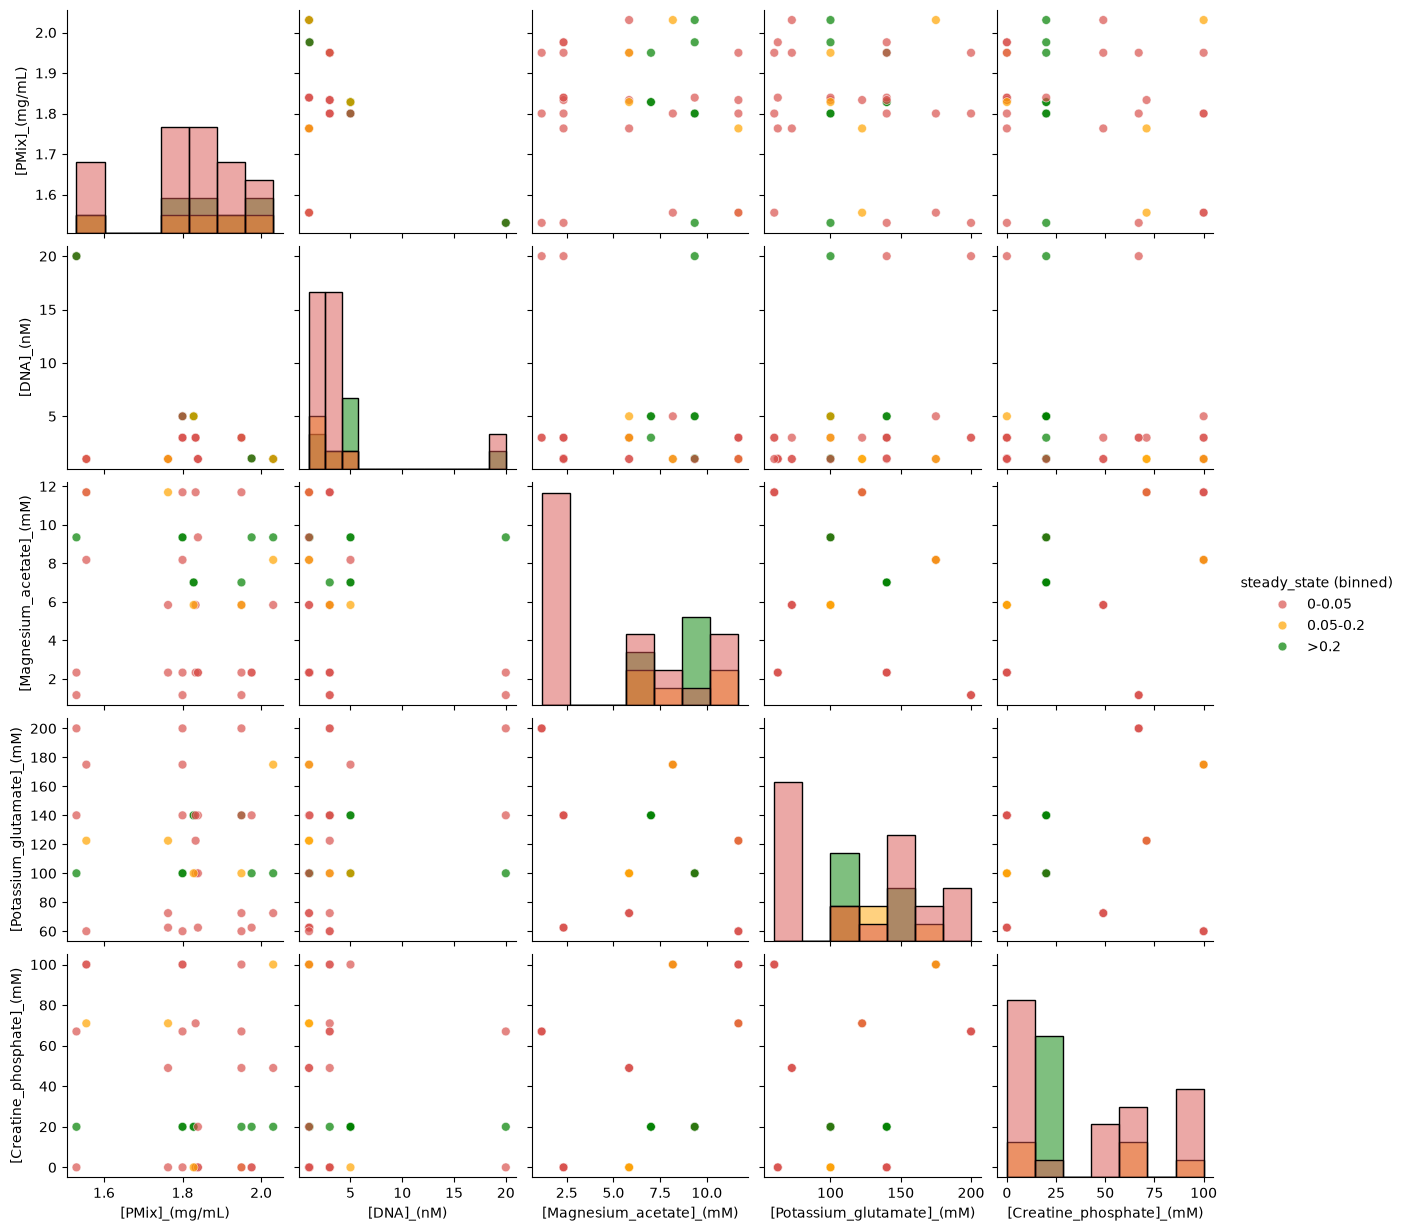

In [28]:
import seaborn as sns
kin['steady_state (binned)'] = pd.cut(                                                                                                                                                                                   
  kin['Steady_State_data_normalized'],                                                                                                                                                                        
  bins=[0, 0.05, 0.2, 1.0],                                                                                                                                                                                   
  labels=['0-0.05', '0.05-0.2', '>0.2']                                                                                                                                                                               
)                                                                                                                                                                                                               

g = sns.pairplot(
  kin[factors + ['steady_state (binned)']],
  vars=factors,
  hue='steady_state (binned)',
  palette={'0-0.05': '#d9534f', '0.05-0.2': 'orange', '>0.2': 'green'},
  plot_kws={'alpha': 0.7, 's': 40},
  diag_kind='hist',
)